In [2]:
import os
import torch
import numpy as np
import json
import trimesh
import matplotlib.pyplot as plt
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.decomposition import FastICA
from tqdm import tqdm
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import FloatSlider, interact, HBox, VBox, Box, IntSlider, Dropdown
from IPython.display import display, HTML
import meshplot as mp
from sklearn.decomposition import PCA
from deep_sdf import data, utils, mesh
import deep_sdf.workspace as ws
import networks.sdf_vae as vae

In [6]:
# Path to experiment directory
#experiment_directory = "examples/torus"
experiment_directory = "examples/OAI-ZIB"

# Load specs for paths
specs_filename = os.path.join(experiment_directory, "specs.json")
specs = json.load(open(specs_filename))

# Path to torus dataset and test split
torus_path = "/home/jakaria/final_classification_dataset_femur/all_mesh/scaled_obj_files"
test_split_file = specs["TrainSplit"]  

# Fix the path by removing any trailing quotes
if torus_path.endswith("'"):
    torus_path = torus_path.rstrip("'")
    print(f"Fixed torus_path: {torus_path}")

# Load the test split
with open(test_split_file, "r") as f:
    test_split = json.load(f)

print(f"Loaded {len(test_split)} test examples")

Loaded 131 test examples


In [7]:
# Function to sample points from a mesh
def sample_points_from_mesh(mesh_path, n_points=5000):
    try:
        mesh = trimesh.load(mesh_path)
        points, _ = trimesh.sample.sample_surface(mesh, n_points)
        return points.flatten()
    except Exception as e:
        print(f"Error processing {mesh_path}: {e}")
        return None

In [8]:
n_points = 5000  # Number of points to sample from each mesh
point_clouds = []
valid_filenames = []
mesh_objects = {}  # Store mesh objects for later visualization

print("Processing meshes...")
for mesh_name in tqdm(test_split, desc="Processing meshes"):
    mesh_path = os.path.join(torus_path, mesh_name)
    if os.path.exists(mesh_path):
        points = sample_points_from_mesh(mesh_path, n_points)
        if points is not None:
            point_clouds.append(points)
            valid_filenames.append(f"{mesh_name}")
            mesh_objects[mesh_name] = trimesh.load(mesh_path)
    else:
        print(f"Mesh file not found: {mesh_path}")

Processing meshes...


Processing meshes: 100%|██████████| 131/131 [02:23<00:00,  1.10s/it]


In [11]:
# Convert to numpy array
X = np.array(point_clouds)
print(f"Dataset shape: {X.shape}")

Dataset shape: (131, 15000)


In [13]:
# Load all labels from the label.pt file
data_source = specs["DataSource"]
labels_path = os.path.join(data_source, "labels.pt")

if os.path.exists(labels_path):
    print(f"Loading labels from {labels_path}")
    all_labels = torch.load(labels_path)
    
    # Extract parameters for each filename
    mesh_params = []
    for filename in valid_filenames:
        # Extract base name without extension to match with label dict key
        base_name = os.path.splitext(os.path.basename(filename))[0]
        
        params = {}
        if base_name in all_labels:
            label = all_labels[base_name]
            params["has_bump"] = int(label)  # bump info at index 0
            #params["bump_size"] = float(label[3].item())  # bump size info at index 1
            #params["scale"] = float(label[2].item())   # scale info at index 2
            #params["sub_group"] = int(label[4].item())  # subgroup info at index 3
            #print(f"Label for {base_name}: {params}")
        else:
            print(f"Warning: No label found for {base_name}")
            params["has_bump"] = 0
            #params["bump_size"] = 0.0
            #params["scale"] = 0.0
            #params["sub_group"] = 0
        
        mesh_params.append(params)

Loading labels from /home/jakaria/final_classification_dataset_femur/all_mesh/sdf_data_aug/SdfSamples/scaled_obj_files_aug/labels.pt


In [14]:
print(mesh_params)

[{'has_bump': 4}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 1}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 1}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 1}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 1}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 0}, {'has_bump': 4}, {'has_bump': 

In [15]:
# Create color coding for visualization based on extracted parameters
has_bump = np.array([p.get("has_bump", 0) for p in mesh_params])
#scales = np.array([p.get("scale", 0) for p in mesh_params])
#sub_groups = np.array([p.get("sub_group", 0) for p in mesh_params])
#bump_sizes = np.array([p.get("bump_size", 0) for p in mesh_params])

In [28]:
# Step 2: Apply HLLE for non-linear dimensionality reduction
n_neighbors = min(400, len(X) - 1)  # Ensuring n_neighbors is valid
print("Applying HLLE (this may take a while for large datasets)...")
hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors, n_components=8, method='hessian', eigen_solver='dense')
Z = hlle.fit_transform(X)
print(f"HLLE embedding shape: {Z.shape}")

Applying HLLE (this may take a while for large datasets)...
HLLE embedding shape: (131, 8)


In [29]:
# Step 3: Apply ICA for disentanglement
print("Applying FastICA...")
ica = FastICA(n_components=8, random_state=42)
Y = ica.fit_transform(Z)
print(f"ICA components shape: {Y.shape}")

Applying FastICA...
ICA components shape: (131, 8)


In [30]:
# Save the results
np.save('latent_factors.npy', Y)
np.save('hlle_embedding.npy', Z)
with open('valid_filenames.json', 'w') as f:
    json.dump(valid_filenames, f)

In [31]:
# Create a DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Component 1': Y[:, 0],
    'Component 2': Y[:, 1],
    'Filename': valid_filenames,
    'Has Bump': has_bump,
    #'Scale': scales,
    #'Subgroup': sub_groups, 
    #'Bump Size': bump_sizes
})

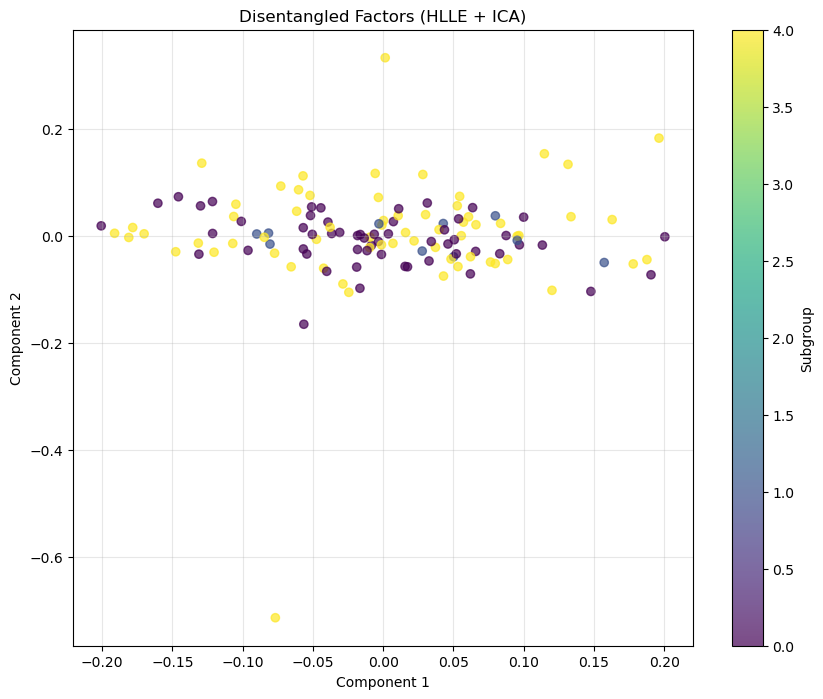

In [36]:
# VISUALIZATION 1: Basic scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(Z[:, 0], Z[:, 3], c=has_bump, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Subgroup")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
#plt.xlim(-0.1, 0.1)
#plt.ylim(-0.1, 0.1)
plt.title("Disentangled Factors (HLLE + ICA)")
plt.grid(True, alpha=0.3)
plt.savefig("torus_latent_factors_bump.png", dpi=300)
plt.show()

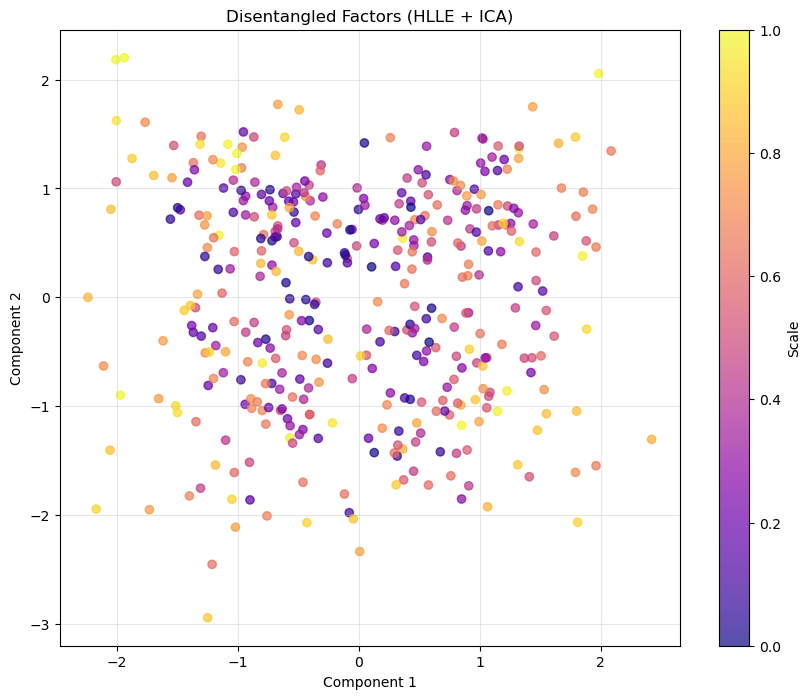

In [13]:
# Alternative coloring by scale
plt.figure(figsize=(10, 8))
if np.any(scales != 0): 
    scatter = plt.scatter(Y[:, 0], Y[:, 3], c=scales, cmap='plasma', alpha=0.7)
    plt.colorbar(scatter, label="Scale")
else:
    scatter = plt.scatter(Y[:, 0], Y[:, 1], alpha=0.7)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
#plt.xlim(-0.2, 0.2)
#plt.ylim(-0.2, 0.2)
plt.title("Disentangled Factors (HLLE + ICA)")
plt.grid(True, alpha=0.3)
plt.savefig("torus_latent_factors_scale.png", dpi=300)
plt.show()

In [37]:
# Optional: Correlation analysis
if len(mesh_params) > 0:
    print("\nCorrelation Analysis:")
    for i in range(Y.shape[1]):
        if np.any(has_bump != 0):
            bump_corr = np.corrcoef(Y[:, i], has_bump)[0, 1]
            print(f"Component {i+1} correlation with bump feature: {bump_corr:.4f}")
        '''
        if np.any(scales != 0):
            scale_corr = np.corrcoef(Y[:, i], scales)[0, 1]
            print(f"Component {i+1} correlation with scale feature: {scale_corr:.4f}")

        if np.any(sub_groups != 0):
            subgroup_corr = np.corrcoef(Y[:, i], sub_groups)[0, 1]
            print(f"Component {i+1} correlation with subgroup feature: {subgroup_corr:.4f}")
        '''


Correlation Analysis:
Component 1 correlation with bump feature: 0.1660
Component 2 correlation with bump feature: -0.0605
Component 3 correlation with bump feature: -0.0553
Component 4 correlation with bump feature: 0.0278
Component 5 correlation with bump feature: 0.0189
Component 6 correlation with bump feature: 0.0046
Component 7 correlation with bump feature: 0.2179
Component 8 correlation with bump feature: 0.0528


KeyError: 'sub_group'

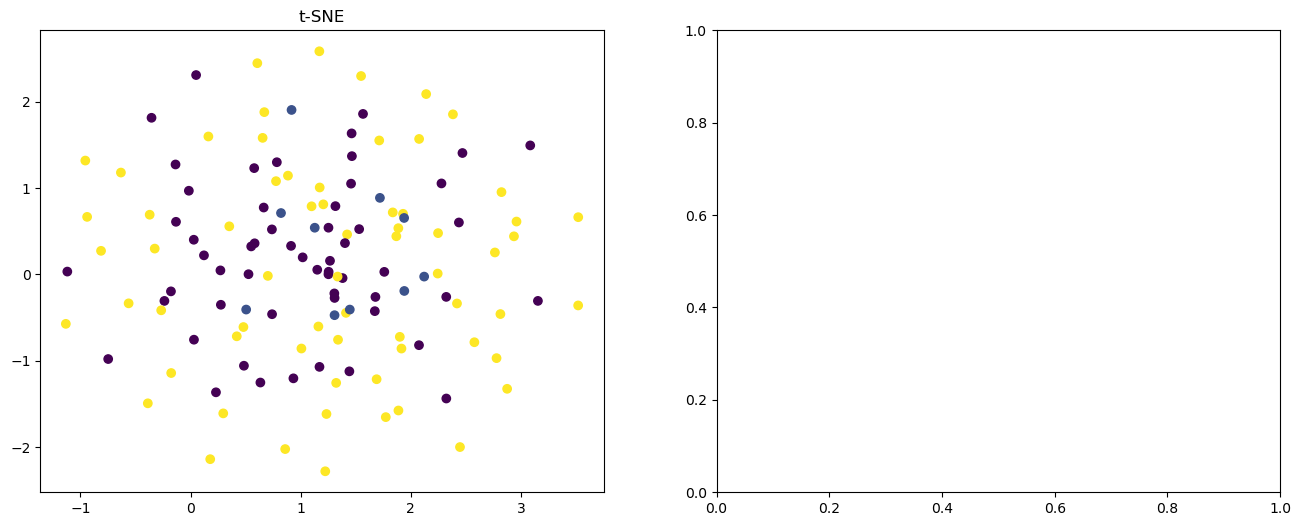

In [26]:
# t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
Y_tsne = tsne.fit_transform(X)

# Plot 
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c=np.array([p["has_bump"] for p in mesh_params]))
plt.title("t-SNE")

plt.subplot(1, 2, 2)
plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c=np.array([p["sub_group"] for p in mesh_params]))
plt.title("t-SNE")
plt.colorbar()
plt.show()

In [27]:
# 1. Try PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
Y_pca = pca.fit_transform(X)

# Plot PCA and calculate correlations
has_bump = np.array([p["has_bump"] for p in mesh_params])
scale = np.array([p["scale"] for p in mesh_params])
sub_group = np.array([p["sub_group"] for p in mesh_params])


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(Y_pca[:, 0], Y_pca[:, 1], c=has_bump)
plt.title("PCA - Colored by Bump")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(Y_pca[:, 1], Y_pca[:, 2], c=scales)
plt.title("PCA - Colored by Scale")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.subplot(1, 2, 2)
plt.scatter(Y_pca[:, 0], Y_pca[:, 1], c=sub_group)
plt.title("PCA - Colored by Sub group")
plt.colorbar()
plt.tight_layout()
plt.show()

pca_corr_scale_dim1 = np.corrcoef(Y_pca[:, 0], scale)[0, 1]
pca_corr_scale_dim2 = np.corrcoef(Y_pca[:, 1], scale)[0, 1]
pca_corr_scale_dim3 = np.corrcoef(Y_pca[:, 2], scale)[0, 1]
pca_corr_scale_dim4 = np.corrcoef(Y_pca[:, 3], scale)[0, 1]
pca_corr_scale_dim5 = np.corrcoef(Y_pca[:, 4], scale)[0, 1]
print(f"PCA - Scale correlation: dim1={pca_corr_scale_dim1:.3f}, dim2={pca_corr_scale_dim2:.3f}, dim3={pca_corr_scale_dim3:.3f}, dim4={pca_corr_scale_dim4:.3f}, dim5={pca_corr_scale_dim5:.3f}")

pca_corr_bump_dim1 = np.corrcoef(Y_pca[:, 0], has_bump)[0, 1]
pca_corr_bump_dim2 = np.corrcoef(Y_pca[:, 1], has_bump)[0, 1]
pca_corr_bump_dim3 = np.corrcoef(Y_pca[:, 2], has_bump)[0, 1]
pca_corr_bump_dim4 = np.corrcoef(Y_pca[:, 3], has_bump)[0, 1]
pca_corr_bump_dim5 = np.corrcoef(Y_pca[:, 4], has_bump)[0, 1]
print(f"PCA - Bump correlation: dim1={pca_corr_bump_dim1:.3f}, dim2={pca_corr_bump_dim2:.3f}, dim3={pca_corr_bump_dim3:.3f}, dim4={pca_corr_bump_dim4:.3f}, dim5={pca_corr_bump_dim5:.3f}")

pca_corr_subgroup_dim1 = np.corrcoef(Y_pca[:, 0], sub_group)[0, 1]
pca_corr_subgroup_dim2 = np.corrcoef(Y_pca[:, 1], sub_group)[0, 1]
pca_corr_subgroup_dim3 = np.corrcoef(Y_pca[:, 2], sub_group)[0, 1]
pca_corr_subgroup_dim4 = np.corrcoef(Y_pca[:, 3], sub_group)[0, 1]
pca_corr_subgroup_dim5 = np.corrcoef(Y_pca[:, 4], sub_group)[0, 1]
print(f"PCA - Subgroup correlation: dim1={pca_corr_subgroup_dim1:.3f}, dim2={pca_corr_subgroup_dim2:.3f}, dim3={pca_corr_subgroup_dim3:.3f}, dim4={pca_corr_subgroup_dim4:.3f}, dim5={pca_corr_subgroup_dim5:.3f}")# 2. Check if scale is encoded as distance from center in pca

# Calculate distance from center for each point
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center)**2, axis=1))

# Check correlation between distance and scale
dist_scale_corr = np.corrcoef(distances, scale)[0, 1]
print(f"Correlation between pca distance from center and scale: {dist_scale_corr:.3f}")

# 2. Check if scale is encoded as distance from center in t-SNE
# For the original t-SNE with perplexity=30
tsne = TSNE(n_components=2, perplexity=30)
Y_tsne = tsne.fit_transform(X)

# Calculate distance from center for each point
center = np.mean(Y_tsne, axis=0)
distances = np.sqrt(np.sum((Y_tsne - center)**2, axis=1))

# Check correlation between distance and scale
dist_scale_corr = np.corrcoef(distances, scale)[0, 1]
print(f"Correlation between t-SNE distance from center and scale: {dist_scale_corr:.3f}")


KeyError: 'scale'

NMF components shape: (400, 4)


Text(0, 0.5, 'Component 2')

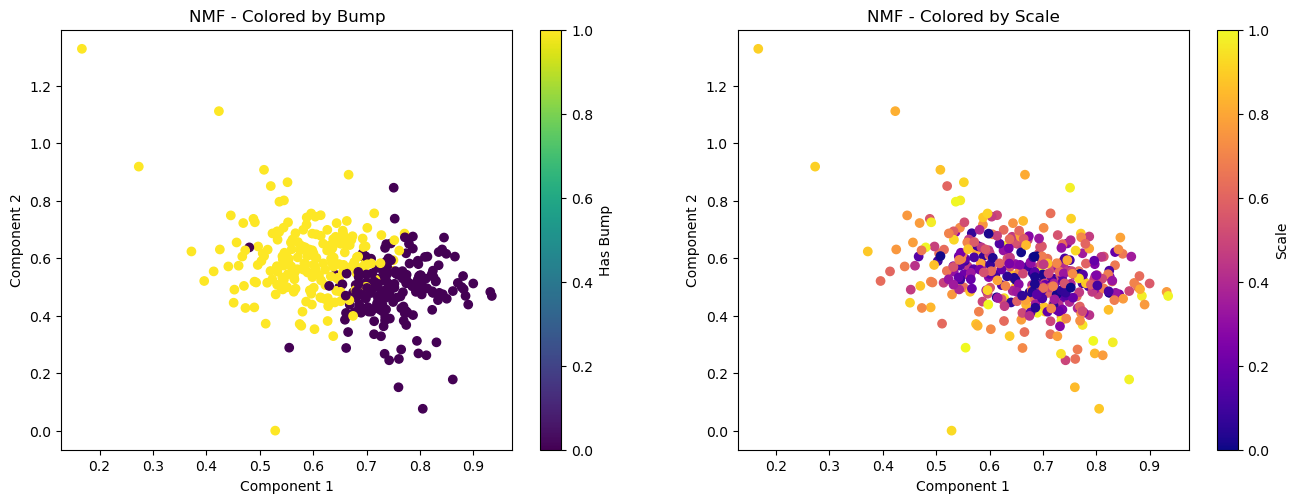

In [44]:
from sklearn.decomposition import NMF
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Ensure data is non-negative
# NMF requires non-negative values, so we need to transform the data
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min  # Shift data to make all values non-negative
else:
    X_offset = X.copy()

# Step 2: Apply NMF
n_components = 4  # Number of factors to discover
nmf = NMF(n_components=n_components, init='random', random_state=42, max_iter=10000)
Y_nmf = nmf.fit_transform(X_offset)

print(f"NMF components shape: {Y_nmf.shape}")
#print(f"NMF reconstruction error: {nmf.reconstruction_err_}")

# Step 3: Visualize the results
plt.figure(figsize=(16, 12))

# NMF colored by bump
plt.subplot(2, 2, 1)
plt.scatter(Y_nmf[:, 0], Y_nmf[:, 1], c=np.array([p["has_bump"] for p in mesh_params]), cmap='viridis')
plt.colorbar(label="Has Bump")
plt.title("NMF - Colored by Bump")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

# NMF colored by scale
plt.subplot(2, 2, 2)
plt.scatter(Y_nmf[:, 0], Y_nmf[:, 1], c=np.array([p["scale"] for p in mesh_params]), cmap='plasma')
plt.colorbar(label="Scale")
plt.title("NMF - Colored by Scale")
plt.xlabel("Component 1")
plt.ylabel("Component 2")


In [45]:
# use loop instead of the above step 4 calculation 
# Step 4: Check correlations with known factors
bump_values = np.array([p["has_bump"] for p in mesh_params])
scale_values = np.array([p["scale"] for p in mesh_params])
# calculate correlations for all the 4 factors
for i in range(Y_nmf.shape[1]):
    nmf_corr_bump = np.corrcoef(Y_nmf[:, i], bump_values)[0, 1]
    nmf_corr_scale = np.corrcoef(Y_nmf[:, i], scale_values)[0, 1]
    print(f"NMF Component {i+1} correlation with bump: {nmf_corr_bump:.3f}")
    print(f"NMF Component {i+1} correlation with scale: {nmf_corr_scale:.3f}")


NMF Component 1 correlation with bump: -0.735
NMF Component 1 correlation with scale: -0.099
NMF Component 2 correlation with bump: 0.427
NMF Component 2 correlation with scale: 0.026
NMF Component 3 correlation with bump: -0.436
NMF Component 3 correlation with scale: 0.010
NMF Component 4 correlation with bump: 0.425
NMF Component 4 correlation with scale: 0.020


Applying FastICA...
ICA components shape: (131, 2)


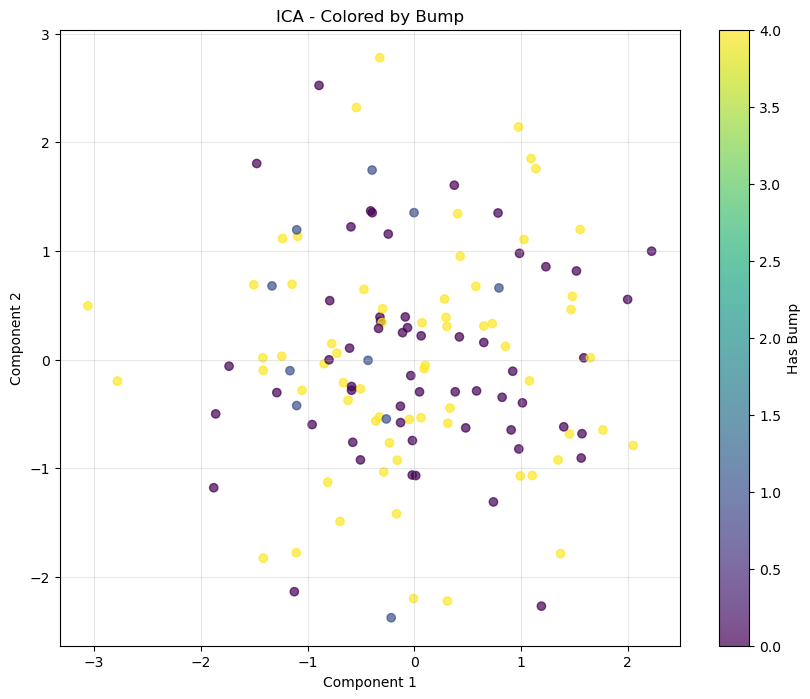

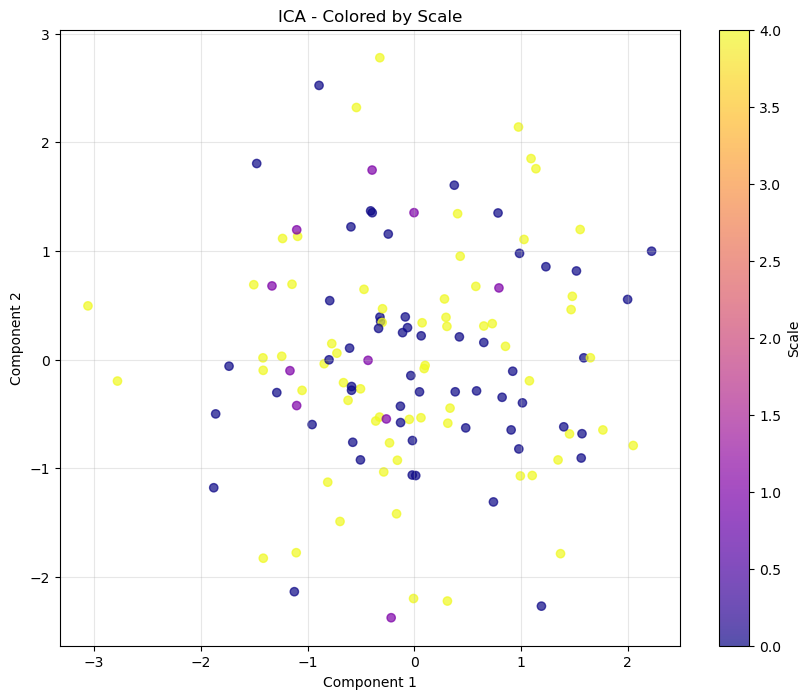

ICA Component 1 correlation with bump: -0.025
ICA Component 2 correlation with bump: -0.013
ICA Component 1 correlation with scale: -0.025
ICA Component 2 correlation with scale: -0.013
Correlation between ICA distance from center and scale: 0.094


In [38]:
# Applying only ICA
print("Applying FastICA...")
ica = FastICA(n_components=2, random_state=42)
Y_ica = ica.fit_transform(X)
print(f"ICA components shape: {Y_ica.shape}")
# Visualize the results
plt.figure(figsize=(10, 8))
plt.scatter(Y_ica[:, 0], Y_ica[:, 1], c=has_bump, cmap='viridis', alpha=0.7)
plt.colorbar(label="Has Bump")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("ICA - Colored by Bump")
plt.grid(True, alpha=0.3)
plt.show()

# visualize scale
plt.figure(figsize=(10, 8))
if np.any(has_bump != 0):
    scatter = plt.scatter(Y_ica[:, 0], Y_ica[:, 1], c=has_bump, cmap='plasma', alpha=0.7)
    plt.colorbar(scatter, label="Scale")
else:
    scatter = plt.scatter(Y_ica[:, 0], Y_ica[:, 1], alpha=0.7)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("ICA - Colored by Scale")
plt.grid(True, alpha=0.3)
plt.show()
# Check correlations with known factors
ica_corr_bump_1 = np.corrcoef(Y_ica[:, 0], has_bump)[0, 1]
ica_corr_bump_2 = np.corrcoef(Y_ica[:, 1], has_bump)[0, 1]
ica_corr_scale_1 = np.corrcoef(Y_ica[:, 0], has_bump)[0, 1]
ica_corr_scale_2 = np.corrcoef(Y_ica[:, 1], has_bump)[0, 1]

print(f"ICA Component 1 correlation with bump: {ica_corr_bump_1:.3f}")
print(f"ICA Component 2 correlation with bump: {ica_corr_bump_2:.3f}")
print(f"ICA Component 1 correlation with scale: {ica_corr_scale_1:.3f}")
print(f"ICA Component 2 correlation with scale: {ica_corr_scale_2:.3f}")

# check if scale is encoded as distance from center
# Calculate distance from center for each point
center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center)**2, axis=1))
# Check correlation between distance and scale
dist_scale_corr = np.corrcoef(distances, has_bump)[0, 1]  
print(f"Correlation between ICA distance from center and scale: {dist_scale_corr:.3f}")



Text(0, 0.5, 'Component 2')

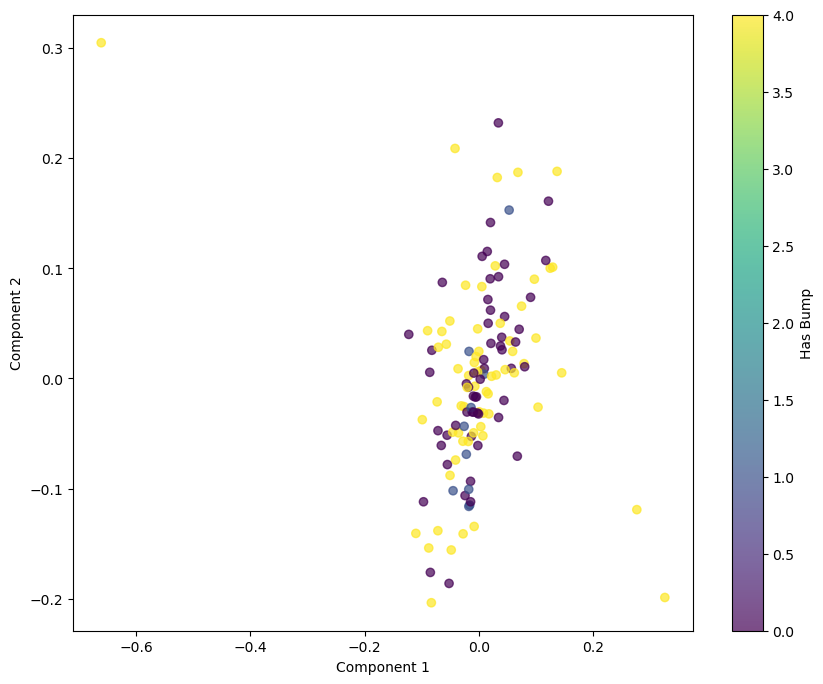

In [40]:
# do PCA on the HLLE embedding
pca_hlle = PCA(n_components=2)
Y_pca_hlle = pca_hlle.fit_transform(Z)
# Plot PCA of HLLE embedding
plt.figure(figsize=(10, 8))
plt.scatter(Y_pca_hlle[:, 0], Y_pca_hlle[:, 1], c=has_bump, cmap='viridis', alpha=0.7)
plt.colorbar(label="Has Bump")
plt.xlabel("Component 1")
plt.ylabel("Component 2")       